<h1>1. Import libraries</h1>

In [1]:
import math
import time
import random
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F

from datasets import load_dataset
from tqdm.auto import tqdm

import matplotlib.pyplot as plt

# -----------------------------
# Set random seed for reproducibility
# -----------------------------
seed = 42  # you can choose any number
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"Random seed set to {seed}")

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

configs = {
    "batch_size": 64,
    "path2Save": "/kaggle/working/char_rnn_best.pt",
    "epochs": 20,
    "lr":1e-3, 
    "seq_len": 100,
    "modelRun": "RNN",
    "hidden_dim": 256,
}

Random seed set to 42
Using cuda device


In [2]:
!git clone https://github.com/MarcellusZhao/Build-GPT-from-scratch

Cloning into 'Build-GPT-from-scratch'...
remote: Enumerating objects: 66, done.
remote: Counting objects: 100% (66/66), done.
remote: Compressing objects: 100% (42/42), done.
remote: Total 66 (delta 27), reused 53 (delta 17), pack-reused 0 (from 0)
Receiving objects: 100% (66/66), 529.41 KiB | 15.13 MiB/s, done.
Resolving deltas: 100% (27/27), done.


<h1>2. Loading, handling, and preparing dataset</h1>

In [3]:
from datasets import load_dataset

dataset = load_dataset(
    "text",
    data_files="/kaggle/working/Build-GPT-from-scratch/data/input.txt"
)
text = "\n".join(dataset['train']['text'])
print("Num Chars. in dataset:", len(text))
print(text[:300])

Generating train split: 0 examples [00:00, ? examples/s]

Num Chars. in dataset: 1115393
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us


In [4]:
chars = sorted(list(set(text)))
print(chars)
vocab_size = len(chars)

char_encode = {ch: i for i, ch in enumerate(chars)}
rev_char_encode = {i: ch for ch, i in char_encode.items()}

print(f"\nchar_encode: {char_encode}")

print(f"\nrev_char_encode: {rev_char_encode}")

['\n', ' ', '!', '$', '&', "'", ',', '-', '.', '3', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']

char_encode: {'\n': 0, ' ': 1, '!': 2, '$': 3, '&': 4, "'": 5, ',': 6, '-': 7, '.': 8, '3': 9, ':': 10, ';': 11, '?': 12, 'A': 13, 'B': 14, 'C': 15, 'D': 16, 'E': 17, 'F': 18, 'G': 19, 'H': 20, 'I': 21, 'J': 22, 'K': 23, 'L': 24, 'M': 25, 'N': 26, 'O': 27, 'P': 28, 'Q': 29, 'R': 30, 'S': 31, 'T': 32, 'U': 33, 'V': 34, 'W': 35, 'X': 36, 'Y': 37, 'Z': 38, 'a': 39, 'b': 40, 'c': 41, 'd': 42, 'e': 43, 'f': 44, 'g': 45, 'h': 46, 'i': 47, 'j': 48, 'k': 49, 'l': 50, 'm': 51, 'n': 52, 'o': 53, 'p': 54, 'q': 55, 'r': 56, 's': 57, 't': 58, 'u': 59, 'v': 60, 'w': 61, 'x': 62, 'y': 63, 'z': 64}

rev_char_encode: {0: '\n', 1: ' ', 2: '!', 3: '$', 4: '&', 5: "'", 6: ',', 7: '-'

In [5]:
fall_back = char_encode.get(" ", 0)
print(fall_back)
def encode(s: str) -> torch.tensor:
    return torch.tensor([char_encode.get(ch, fall_back) for ch in s], dtype=torch.long)
    
def decode(ids) -> str:
    return "".join([rev_char_encode[int(i)] for i in ids])

print(text[0])
data = encode(text)
print("Encoded data shape: ", data[0])
dataAfterDecoder = decode(data)
print("Decoder data shape: ", dataAfterDecoder[0])

1
F
Encoded data shape:  tensor(18)
Decoder data shape:  F


In [6]:
N = len(data)

train_end = int(0.9 * N)
val_end = int(0.95 * N)

train_ids = data[:train_end]
val_ids = data[train_end:val_end]
test_ids = data[val_end:]

print(len(train_ids), len(val_ids), len(test_ids))

1003853 55770 55770


In [7]:
def batch(data: torch.Tensor, batch_size: int) -> torch.Tensor:
    n_batches = data.size(0) // batch_size
    data = data[:n_batches * batch_size]
    return data.view(batch_size, -1)

In [8]:
train_data = batch(train_ids, configs['batch_size']).to(device)
val_data = batch(val_ids, configs['batch_size']).to(device)
test_data = batch(test_ids, configs['batch_size']).to(device)

print(train_data.shape)

torch.Size([64, 15685])


In [9]:
def get_batch(data: torch.Tensor, i: int, seq_len: int):
    seq_len = min(seq_len, data.size(1) - 1 - i)
    X = data[:, i:i+seq_len]
    Y = data[:, i+1:i+seq_len+1]
    return X, Y

<h1>3. Creating Model</h1>

In [10]:
class VanillaRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim = 64, hidden_dim = 128):
        super().__init__()
        
        self.hidden_dim = hidden_dim
        
        # Embedding layer
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        
        # RNN parameters
        self.Wx = nn.Linear(embed_dim, hidden_dim)
        self.Wh = nn.Linear(hidden_dim, hidden_dim)
        
        # Output layer
        self.Wy = nn.Linear(hidden_dim, vocab_size)
        
    def forward(self, x, h_prev=None):
        """
        x: [B, T] (token indices)
        h_prev: [B, hidden_dim]
        """
        B, T = x.shape
        
        if h_prev is None:
            h_prev = torch.zeros(B, self.hidden_dim, device=x.device)
        
        embeddings = self.embedding(x)  # [B, T, embed_dim]
        
        outputs = []
        h = h_prev
        
        for t in range(T):
            x_t = embeddings[:, t, :]
            
            # Vanilla RNN update
            h = torch.tanh(self.Wh(h) + self.Wx(x_t))
            
            # Output prediction
            y_t = self.Wy(h)
            outputs.append(y_t)
        
        outputs = torch.stack(outputs, dim=1)  # [B, T, vocab_size]
        
        return outputs, h

In [11]:
class LSTMCell(nn.Module):
    def __init__(self,  embed_dim = 128, hidden_dim = 128):
        super().__init__()
        
        self.hidden_dim = hidden_dim
        
        # Forget gate
        self.Wf = nn.Linear(embed_dim, hidden_dim)
        self.Uf = nn.Linear(hidden_dim, hidden_dim)
        self.bf = nn.Parameter(torch.zeros(hidden_dim))
        
        # Input gate
        self.Wi = nn.Linear(embed_dim, hidden_dim)
        self.Ui = nn.Linear(hidden_dim, hidden_dim)
        self.bi = nn.Parameter(torch.zeros(hidden_dim))
        
        # Candidate memory
        self.Wc = nn.Linear(embed_dim, hidden_dim)
        self.Uc = nn.Linear(hidden_dim, hidden_dim)
        self.bc = nn.Parameter(torch.zeros(hidden_dim))
        
        # Output gate
        self.Wo = nn.Linear(embed_dim, hidden_dim)
        self.Uo = nn.Linear(hidden_dim, hidden_dim)
        self.bo = nn.Parameter(torch.zeros(hidden_dim))

    def forward(self, x_t, h_prev, c_prev):
        
        # ===== Forget Gate =====
        f_t = torch.sigmoid(
            self.Wf(x_t) + self.Uf(h_prev) + self.bf
        )
        
        # ===== Input Gate =====
        i_t = torch.sigmoid(
            self.Wi(x_t) + self.Ui(h_prev) + self.bi
        )
        
        # ===== Candidate Memory =====
        c_tilde = torch.tanh(
            self.Wc(x_t) + self.Uc(h_prev) + self.bc
        )
        
        # ===== Cell State Update =====
        c_t = f_t * c_prev + i_t * c_tilde
        
        # ===== Output Gate =====
        o_t = torch.sigmoid(
            self.Wo(x_t) + self.Uo(h_prev) + self.bo
        )
        
        # ===== Hidden State =====
        h_t = o_t * torch.tanh(c_t)
        
        return h_t, c_t

class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_dim = 128, hidden_dim = 128):
        super().__init__()
        
        self.hidden_dim = hidden_dim
        self.vocab_size = vocab_size
        
        # Embedding
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        
        # LSTM Cell
        self.cell = LSTMCell(embed_dim, hidden_dim)
        
        # Output head
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, states=None):
        """
        x: [B, T]
        """
        B, T = x.shape
        
        if states is None:
            h = torch.zeros(B, self.hidden_dim, device=x.device)
            c = torch.zeros(B, self.hidden_dim, device=x.device)
        else:
            h, c = states
        
        embeddings = self.embedding(x)  # [B, T, embed_dim]
        
        outputs = []
        
        for t in range(T):
            x_t = embeddings[:, t, :]
            
            # 🔥 Apply LSTM CELL (EXPLICIT)
            h, c = self.cell(x_t, h, c)
            
            outputs.append(h)
        
        outputs = torch.stack(outputs, dim=1)  # [B, T, hidden]
        
        logits = self.fc(outputs)  # [B, T, vocab]
        
        return logits, (h, c)

In [12]:
if configs['modelRun'] == "RNN":
    model = VanillaRNN(vocab_size=vocab_size, hidden_dim = configs['hidden_dim']).to(device)
elif configs['modelRun'] == "LSTM":
    model = LSTMModel(vocab_size=vocab_size, hidden_dim = configs['hidden_dim']).to(device)
else:
    raise Exception("You should choose 1 model!")
print(model)

VanillaRNN(
  (embedding): Embedding(65, 64)
  (Wx): Linear(in_features=64, out_features=256, bias=True)
  (Wh): Linear(in_features=256, out_features=256, bias=True)
  (Wy): Linear(in_features=256, out_features=65, bias=True)
)


<h1>4. Preparing for training</h1>

In [13]:
loss_fn = nn.CrossEntropyLoss()
optim = torch.optim.AdamW(model.parameters(), lr=configs['lr'])

In [14]:
# =========================
# Train One Epoch
# =========================
def train_one_epoch(model, data, optimizer, loss_fn, seq_len=128, clip_grad=1.0, device="cpu"):
    
    model.train()
    grad_norms = []
    total_loss = 0.0
    count = 0
    
    data = data.to(device)
    B, T_total = data.shape
    
    for i in tqdm(range(0, T_total - seq_len - 1, seq_len), total=((T_total - seq_len - 1) // seq_len), leave=True, colour="blue", desc=f"Processing sequences"):
        
        x = data[:, i : i + seq_len].to(device)
        y = data[:, i + 1 : i + seq_len + 1].to(device)
        
        logits, _ = model(x)
        
        B, T, V = logits.shape
        logits = logits.reshape(B * T, V)
        y = y.reshape(B * T)
        
        loss = loss_fn(logits, y)
        
        optimizer.zero_grad()
        loss.backward()
        
        # ✅ GET gradient norm
        grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), clip_grad)
        grad_norms.append(grad_norm.item())
        
        optimizer.step()
        
        total_loss += loss.item()
        count += 1
    
    avg_loss = total_loss / count
    avg_grad_norm = sum(grad_norms) / len(grad_norms)
    
    return avg_loss, avg_grad_norm


# =========================
# Evaluation
# =========================
@torch.inference_mode()
def evaluate(model, data, loss_fn, device="cpu", seq_len=128):
    
    model.eval()
    
    total_loss = 0.0
    count = 0
    
    data = data.to(device)
    B, T_total = data.shape
    
    for i in tqdm(range(0, T_total - seq_len - 1, seq_len), total=((T_total - seq_len - 1) // seq_len), leave=True, colour="green", desc=f"Processing sequences"):
        
        x = data[:, i : i + seq_len].to(device)
        y = data[:, i + 1 : i + seq_len + 1].to(device)
        
        logits, _ = model(x)
        
        B, T, V = logits.shape
        logits = logits.reshape(B * T, V)
        y = y.reshape(B * T)
        
        loss = loss_fn(logits, y)
        
        total_loss += loss.item()
        count += 1
    
    return total_loss / count


# =========================
# Full Training Loop
# =========================
def train_model(model, train_data, val_data, optimizer, loss_fn, epochs=10, lr=1e-3, seq_len=128, device="cpu"):
    
    model = model.to(device)
    
    optimizer = optimizer
    loss_fn = loss_fn
    
    train_losses = []
    val_losses = []
    time_each_epoch = []
    
    best_val_loss = float("inf")
    
    for epoch in range(1, epochs + 1):
        start_time = time.time()
        
        print(f"\nEpoch {epoch}: ", end="")
        
        train_loss, avg_grad_norm = train_one_epoch(
            model, train_data, optimizer, loss_fn,
            seq_len=seq_len, device=device
        )
        
        val_loss = evaluate(
            model, val_data, loss_fn,
            seq_len=seq_len, device=device
        )
        
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        
        # ✅ Save BEST model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), "best_model.pth")
            print("✅ Saved best model!")

        end_time = time.time()    # Record end time
        time_each_epoch.append(end_time - start_time)
        print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | GradNorm: {avg_grad_norm:.4f} || duration: {time_each_epoch[-1]:.4f}")
    
    return train_losses, val_losses, time_each_epoch

In [15]:
device = "cuda" if torch.cuda.is_available() else "cpu"

train_losses, val_losses, time_each_epoch = train_model(
    model,
    train_data,
    val_data,
    optimizer = optim,
    loss_fn = loss_fn,
    epochs=configs['epochs'],
    lr=configs['lr'],
    seq_len=configs['seq_len'],
    device=device
)


Epoch 1: 

Processing sequences:   0%|          | 0/155 [00:00<?, ?it/s]

Processing sequences:   0%|          | 0/7 [00:00<?, ?it/s]

✅ Saved best model!
Train Loss: 2.4352 | Val Loss: 2.0959 | GradNorm: 0.3032 || duration: 8.2764

Epoch 2: 

Processing sequences:   0%|          | 0/155 [00:00<?, ?it/s]

...

Processing sequences:   0%|          | 0/7 [00:00<?, ?it/s]

✅ Saved best model!
Train Loss: 1.4328 | Val Loss: 1.5820 | GradNorm: 0.3310 || duration: 7.2682

Epoch 20: 

Processing sequences:   0%|          | 0/155 [00:00<?, ?it/s]

Processing sequences:   0%|          | 0/7 [00:00<?, ?it/s]

✅ Saved best model!
Train Loss: 1.4272 | Val Loss: 1.5785 | GradNorm: 0.3312 || duration: 7.1597


<h1>5. Evaluation after train</h1>

In [16]:
print(f"progress_train_loss: {train_losses}\n") 
print(f"progress_val_loss: {val_losses}\n") 

print(f"Total time = {sum(time_each_epoch):.2f}s   ||   average time per epoch = {sum(time_each_epoch)/len(time_each_epoch):.2f}s")

progress_train_loss: [2.435239131634052, 1.9479019259795165, 1.7971943830832458, 1.7092382120780456, 1.6513812022331433, 1.6102032424547734, 1.578806648651759, 1.5538136271330028, 1.5333928030270796, 1.516365233140114, 1.5019027032913306, 1.489415935980968, 1.4784808724354475, 1.468790134558311, 1.4601239164670308, 1.4523244354969416, 1.4452633498570857, 1.438792149990033, 1.4327710011066535, 1.4271808579946175]

progress_val_loss: [2.0959292948246, 1.933635413646698, 1.8467345833778381, 1.7895543575286865, 1.7501588314771652, 1.7205111384391785, 1.6965774893760681, 1.6767476350069046, 1.6601794213056564, 1.64622862637043, 1.634346604347229, 1.624151885509491, 1.6154138445854187, 1.6079283356666565, 1.6014742851257324, 1.5958284735679626, 1.5907202064990997, 1.5860407203435898, 1.5819957256317139, 1.5785276144742966]

Total time = 145.91s   ||   average time per epoch = 7.30s


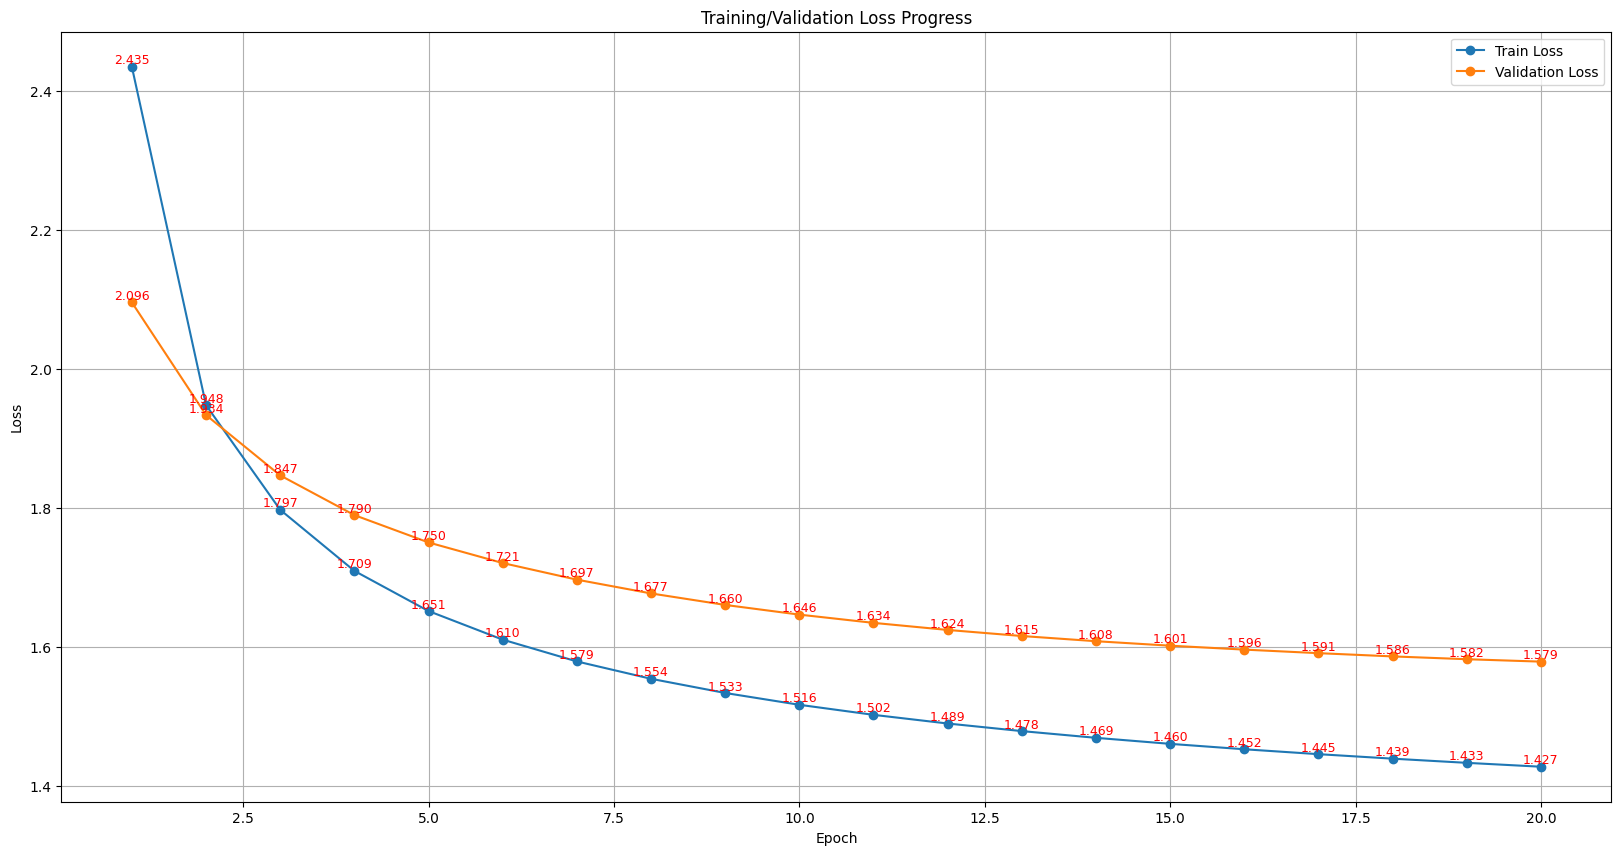

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10)) 

# Epochs starting from 1
x = [i + 1 for i in range(len(train_losses))]

# Plot training and validation losses
plt.plot(x, train_losses, marker='o', label='Train Loss')
plt.plot(x, val_losses, marker='o', label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training/Validation Loss Progress")
plt.legend()
plt.grid(True)

# Show values on each marker
for i, y in enumerate(train_losses):
    plt.text(x[i], y, f"{y:.3f}", ha='center', va='bottom', fontsize=9, color='red')
for i, y in enumerate(val_losses):
    plt.text(x[i], y, f"{y:.3f}", ha='center', va='bottom', fontsize=9, color='red')

plt.show()

<h1>6. Real Test</h1>
<h1>6.1 Loading Trained Weight</h1>

In [18]:
#model = VanillaRNN(vocab_size, embed_dim, hidden_dim)
model.load_state_dict(torch.load("/kaggle/working/best_model.pth", map_location=device))
model = model.to(device)
model.eval()

VanillaRNN(
  (embedding): Embedding(65, 64)
  (Wx): Linear(in_features=64, out_features=256, bias=True)
  (Wh): Linear(in_features=256, out_features=256, bias=True)
  (Wy): Linear(in_features=256, out_features=65, bias=True)
)

In [19]:
def generate_text(model, start_text, stoi, itos, max_len=200, temperature=1.0, device="cpu"):
    """
    start_text: string to start generation
    stoi: char → index
    itos: index → char
    """
    
    model.eval()
    
    # Encode input text
    input_ids = [stoi[c] for c in start_text]
    x = torch.tensor(input_ids, dtype=torch.long).unsqueeze(0).to(device)  # [1, T]
    
    h = None
    generated = start_text
    
    for _ in range(max_len):
        
        # Forward
        logits, h = model(x, h)
        
        # Take last time step
        logits = logits[:, -1, :]   # [1, vocab]
        
        # Apply temperature
        logits = logits / temperature
        
        probs = F.softmax(logits, dim=-1)
        
        # Sample next token
        next_id = torch.multinomial(probs, num_samples=1).item()
        
        # Append
        next_char = itos[next_id]
        generated += next_char
        
        # Next input
        x = torch.tensor([[next_id]], dtype=torch.long).to(device)
    
    return generated

<h1>6.2. Starting Real Text Generate</h1>

In [20]:
text = generate_text(
    model,
    start_text="To be or not to be",
    stoi=char_encode,
    itos=rev_char_encode,
    max_len=2000,
    temperature=0.8,
    device=device
)

print(text)

To be or not to bed,
His affienty than a duke, but and thee, with us the mother shall pitise.

KING RICHARD III:
Marry, if in the comfort, man, your spoth him,
That thou, that great my change of hence; where be honour sun wilt with your heart?
This must 'elm; for he said with thee!--
Which destruster that was down:
The other blood,
We be put mpt much lieges so shear now of him be?
If you that weeps mine of subbrakes a sun.
Have all my sond thee,
My whose fair Richard so take unto the part of all be subdue in the child.

KING RICHARD III:
Well, 'tis can she be so trick, so I say; since there; and there was he wom.

CAMILLO:
I cannot be pardon,
Which rebit, and then thou boy, chaste me by his chuese's man!
Lest he hangs from him.

ESCALUS:
Hall have men thee for
Is steas we and mine eit I think on licks the firder you that shread right; royal presently.

HASTINGS:

BUCKINGHAM:
And such hards, he bear
As you do it, which the man
Shall not shall be show?

KING RICHARD III:
O my cause shall